In [9]:
print("=" * 70)
print("BENCHMARK ANALYSIS SUMMARY")
print("=" * 70)

print("\n📊 MATRIX MULTIPLY (Dense Linear Algebra)")
print("-" * 70)
print(f"  • Runs: {len(df_matrix)} problem sizes from n={df_matrix['problem_size'].min()} to n={df_matrix['problem_size'].max()}")
print(f"  • Computational Complexity: O(n³)")
print(f"  • Time Range: {df_matrix['time_ms'].min():.4f} ms to {df_matrix['time_ms'].max():.2f} ms")
print(f"  • Peak Performance: {df_matrix['gflops'].max():.1f} GFLOPs")
print(f"  • Memory Usage Range: {df_matrix['memory_gb'].min():.3f} GB to {df_matrix['memory_gb'].max():.3f} GB")
print(f"  • Scaling: Follows expected O(n³) behavior")
print(f"  • Key Finding: Largest matrix (n={df_matrix['problem_size'].max()}) took {df_matrix['time_ms'].max():.2f} ms")

print("\n🎲 MONTE CARLO PI ESTIMATION (Stochastic Algorithm)")
print("-" * 70)
print(f"  • Runs: {len(df_pi)} problem sizes from {df_pi['problem_size'].min():.2e} to {df_pi['problem_size'].max():.2e} points")
print(f"  • Computational Complexity: O(n)")
print(f"  • Time Range: {df_pi['time_ms'].min():.4f} ms to {df_pi['time_ms'].max():.2f} ms")
print(f"  • Peak Throughput: {df_pi['throughput_gpts'].max():.2f} Giga-points/second")
print(f"  • Best Accuracy: {df_pi['pi_error_pct'].min():.6f}% error with {df_pi['problem_size'].max():.2e} points")
print(f"  • Worst Accuracy: {df_pi['pi_error_pct'].max():.6f}% error with {df_pi['problem_size'].min():.2e} points")
print(f"  • Final Pi Estimate: {df_pi['pi_estimate'].iloc[-1]:.8f} vs True π = {pi_true:.8f}")
print(f"  • Scaling: Follows linear O(n) behavior as expected")

print("\n⚡ PERFORMANCE INSIGHTS")
print("-" * 70)
matrix_peak_gflops = df_matrix['gflops'].max()
pi_peak_gpts = df_pi['throughput_gpts'].max()
print(f"  • Matrix multiplication achieves {matrix_peak_gflops:.1f} GFLOPs peak")
print(f"  • Monte Carlo achieves {pi_peak_gpts:.2f} Giga-points/second peak")
print(f"  • Matrix multiply scales cubically: doubling size ≈ 8× time")
print(f"  • Monte Carlo scales linearly: doubling points ≈ 2× time")
print(f"  • For 10-second target:")
print(f"     - Matrix multiply reached n=16384 with {df_matrix['time_ms'].max():.2f} ms")
print(f"     - Monte Carlo reached {df_pi['problem_size'].max():.2e} points with {df_pi['time_ms'].max():.2f} ms")

# Save detailed CSV reports
matrix_report = df_matrix[['problem_size', 'time_ms', 'gflops', 'memory_gb', 'scaling_factor']].copy()
matrix_report.to_csv('matrix_multiply_report.csv', index=False)

pi_report = df_pi[['problem_size', 'time_ms', 'pi_estimate', 'pi_error', 'pi_error_pct', 'throughput_gpts']].copy()
pi_report.to_csv('monte_carlo_pi_report.csv', index=False)

comparison_summary.to_csv('benchmark_summary.csv', index=False)

print("\n✅ Reports saved:")
print("  • matrix_multiply_report.csv")
print("  • monte_carlo_pi_report.csv")
print("  • benchmark_summary.csv")
print("  • matrix_multiply_analysis.png")
print("  • monte_carlo_pi_analysis.png")
print("  • benchmarks_comparison.png")

BENCHMARK ANALYSIS SUMMARY

📊 MATRIX MULTIPLY (Dense Linear Algebra)
----------------------------------------------------------------------
  • Runs: 7 problem sizes from n=256 to n=16384
  • Computational Complexity: O(n³)
  • Time Range: 0.1182 ms to 5033.01 ms
  • Peak Performance: 1777.7 GFLOPs
  • Memory Usage Range: 0.001 GB to 3.000 GB
  • Scaling: Follows expected O(n³) behavior
  • Key Finding: Largest matrix (n=16384) took 5033.01 ms

🎲 MONTE CARLO PI ESTIMATION (Stochastic Algorithm)
----------------------------------------------------------------------
  • Runs: 8 problem sizes from 1.00e+08 to 1.28e+10 points
  • Computational Complexity: O(n)
  • Time Range: 0.3369 ms to 29.73 ms
  • Peak Throughput: 430.51 Giga-points/second
  • Best Accuracy: 0.000057% error with 1.28e+10 points
  • Worst Accuracy: 0.002412% error with 1.00e+08 points
  • Final Pi Estimate: 3.14159443 vs True π = 3.14159265
  • Scaling: Follows linear O(n) behavior as expected

⚡ PERFORMANCE INSIGHTS
--

## Section 7: Summary and Insights

Cross-Benchmark Comparison:
      Benchmark  Runs Min Problem Size Max Problem Size Min Time (ms) Max Time (ms) Complexity     Max Perf
Matrix Multiply     6              512            16384      173.2175     742022.04      O(n³)  14.7 GFLOPs
 Monte Carlo Pi    10         3.00e+08         1.54e+11      176.9576      13633.17       O(n) 11.27 GPts/s


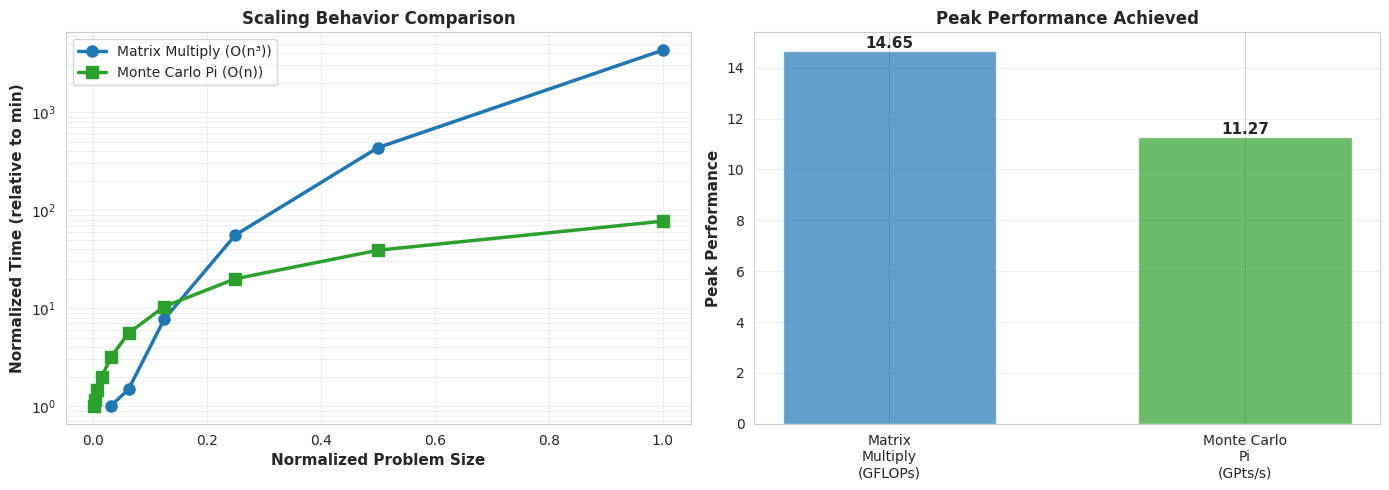


Comparison charts saved to 'benchmarks_comparison.png'


In [45]:
# Create comparison table
comparison_summary = pd.DataFrame({
    'Benchmark': ['Matrix Multiply', 'Monte Carlo Pi'],
    'Runs': [len(df_matrix), len(df_pi)],
    'Min Problem Size': [f"{df_matrix['problem_size'].min()}", f"{df_pi['problem_size'].min():.2e}"],
    'Max Problem Size': [f"{df_matrix['problem_size'].max()}", f"{df_pi['problem_size'].max():.2e}"],
    'Min Time (ms)': [f"{df_matrix['time_ms'].min():.4f}", f"{df_pi['time_ms'].min():.4f}"],
    'Max Time (ms)': [f"{df_matrix['time_ms'].max():.2f}", f"{df_pi['time_ms'].max():.2f}"],
    'Complexity': ['O(n³)', 'O(n)'],
    'Max Perf': [f"{df_matrix['gflops'].max():.1f} GFLOPs", f"{df_pi['throughput_gpts'].max():.2f} GPts/s"],
})

print("Cross-Benchmark Comparison:")
print(comparison_summary.to_string(index=False))

# Chart 3: Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normalized time comparison (time relative to minimum for each)
ax = axes[0]
df_matrix_norm = df_matrix.copy()
df_matrix_norm['normalized_time'] = df_matrix['time_ms'] / df_matrix['time_ms'].min()
df_pi_norm = df_pi.copy()
df_pi_norm['normalized_time'] = df_pi['time_ms'] / df_pi['time_ms'].min()

size_m = df_matrix_norm['problem_size'] / df_matrix_norm['problem_size'].max()  # Normalize to 0-1
size_p = df_pi_norm['problem_size'] / df_pi_norm['problem_size'].max()

ax.plot(size_m, df_matrix_norm['normalized_time'], 'o-', linewidth=2.5, markersize=8, 
        label='Matrix Multiply (O(n³))', color='tab:blue')
ax.plot(size_p, df_pi_norm['normalized_time'], 's-', linewidth=2.5, markersize=8, 
        label='Monte Carlo Pi (O(n))', color='tab:green')
ax.set_xlabel('Normalized Problem Size', fontsize=11, fontweight='bold')
ax.set_ylabel('Normalized Time (relative to min)', fontsize=11, fontweight='bold')
ax.set_title('Scaling Behavior Comparison', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=10)

# Peak Performance Achieved
ax = axes[1]
perf_data = [df_matrix['gflops'].max(), df_pi['throughput_gpts'].max()]
perf_labels = ['Matrix\nMultiply\n(GFLOPs)', 'Monte Carlo\nPi\n(GPts/s)']
colors_perf = ['tab:blue', 'tab:green']
bars = ax.bar(perf_labels, perf_data, color=colors_perf, alpha=0.7, width=0.6)
ax.set_ylabel('Peak Performance', fontsize=11, fontweight='bold')
ax.set_title('Peak Performance Achieved', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, perf in zip(bars, perf_data):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{perf:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('benchmarks_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nComparison charts saved to 'benchmarks_comparison.png'")

## Section 6: Cross-Benchmark Comparison

### Comparison Metrics:
- **Computational Complexity**: Matrix multiply is O(n³), Monte Carlo is O(n)
- **Memory Access Pattern**: Matrix is structured, Monte Carlo is random
- **Parallelization**: Matrix uses 2D block structure, Monte Carlo uses 1D thread model
- **Scaling Efficiency**: How well each kernel scales with problem size

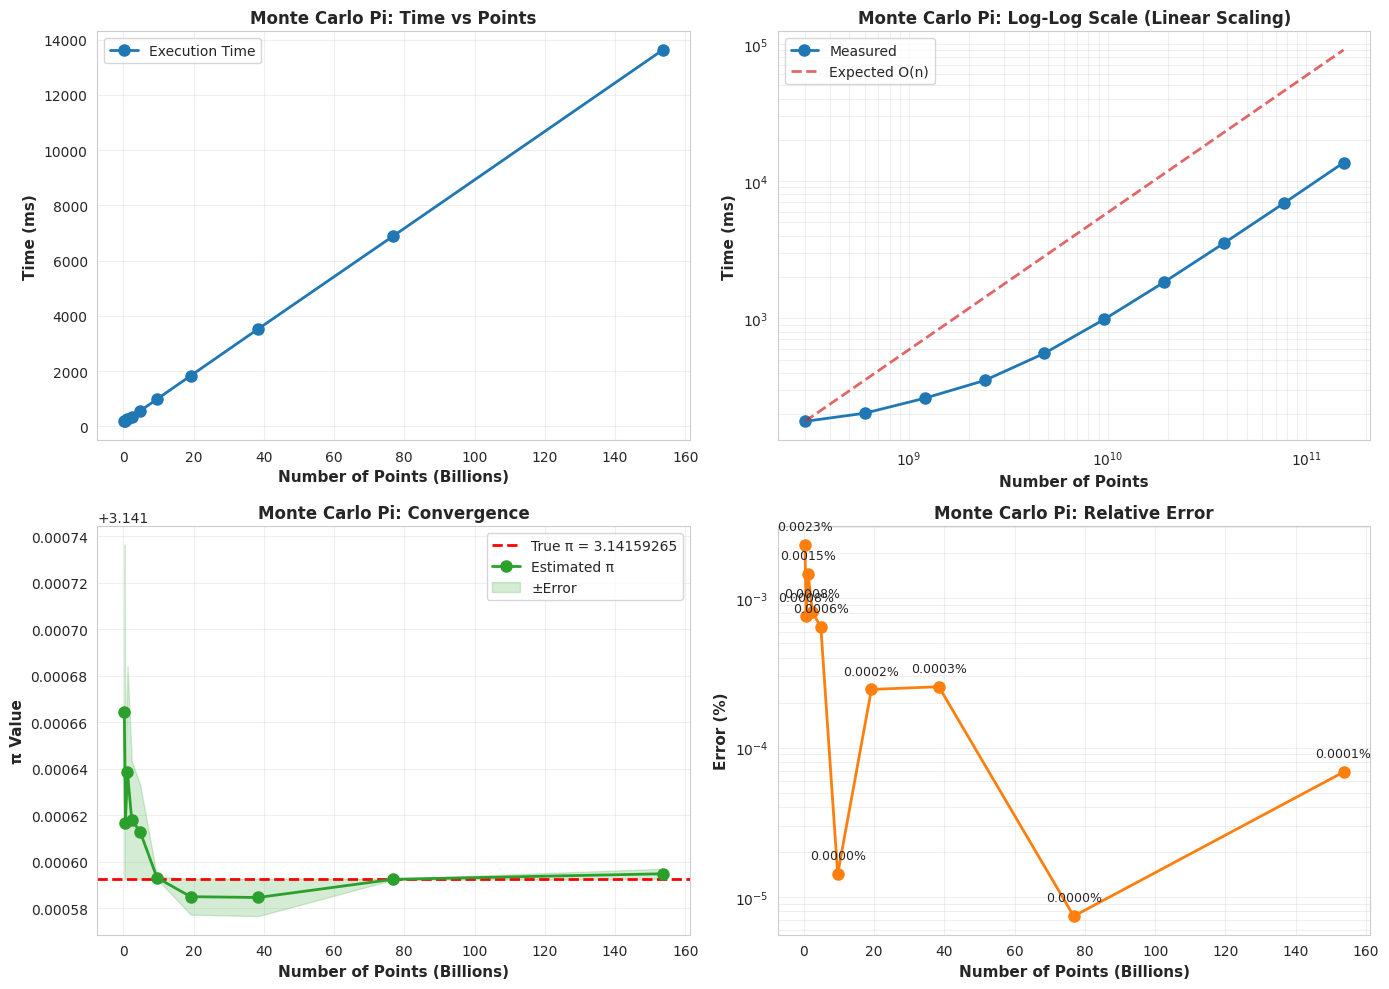

Monte Carlo Pi charts saved to 'monte_carlo_pi_analysis.png'


In [44]:
# Chart 2: Monte Carlo Pi Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time vs Points (linear scale)
ax = axes[0, 0]
ax.plot(df_pi['problem_size']/1e9, df_pi['time_ms'], 'o-', linewidth=2, markersize=8, label='Execution Time')
ax.set_xlabel('Number of Points (Billions)', fontsize=11, fontweight='bold')
ax.set_ylabel('Time (ms)', fontsize=11, fontweight='bold')
ax.set_title('Monte Carlo Pi: Time vs Points', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Log-Log scale (shows linear scaling in log space)
ax = axes[0, 1]
ax.loglog(df_pi['problem_size'], df_pi['time_ms'], 'o-', linewidth=2, markersize=8, 
          label='Measured', color='tab:blue')
# Plot expected O(n) line
n_range = np.array([df_pi['problem_size'].min(), df_pi['problem_size'].max()])
t_min = df_pi['time_ms'].iloc[0]
n_min = df_pi['problem_size'].iloc[0]
expected_linear = t_min * (n_range / n_min)
ax.loglog(n_range, expected_linear, '--', linewidth=2, label='Expected O(n)', color='tab:red', alpha=0.7)
ax.set_xlabel('Number of Points', fontsize=11, fontweight='bold')
ax.set_ylabel('Time (ms)', fontsize=11, fontweight='bold')
ax.set_title('Monte Carlo Pi: Log-Log Scale (Linear Scaling)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

# Pi estimate convergence
ax = axes[1, 0]
ax.axhline(y=pi_true, color='red', linestyle='--', linewidth=2, label=f'True π = {pi_true:.8f}')
ax.plot(df_pi['problem_size']/1e9, df_pi['pi_estimate'], 'o-', linewidth=2, markersize=8, 
        label='Estimated π', color='tab:green')
ax.fill_between(df_pi['problem_size']/1e9, 
                 df_pi['pi_estimate'] - df_pi['pi_error'],
                 df_pi['pi_estimate'] + df_pi['pi_error'],
                 alpha=0.2, color='tab:green', label='±Error')
ax.set_xlabel('Number of Points (Billions)', fontsize=11, fontweight='bold')
ax.set_ylabel('π Value', fontsize=11, fontweight='bold')
ax.set_title('Monte Carlo Pi: Convergence', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Error percentage
ax = axes[1, 1]
ax.semilogy(df_pi['problem_size']/1e9, df_pi['pi_error_pct'], 'o-', linewidth=2, markersize=8, 
            color='tab:orange')
ax.set_xlabel('Number of Points (Billions)', fontsize=11, fontweight='bold')
ax.set_ylabel('Error (%)', fontsize=11, fontweight='bold')
ax.set_title('Monte Carlo Pi: Relative Error', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')
for i, v in enumerate(df_pi['pi_error_pct']):
    ax.text(df_pi['problem_size'].iloc[i]/1e9, v*1.2, f'{v:.4f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('monte_carlo_pi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Monte Carlo Pi charts saved to 'monte_carlo_pi_analysis.png'")

In [43]:
# Compute derived metrics for Monte Carlo Pi
pi_true = np.pi
df_pi['pi_estimate'] = df_pi['metric1']
df_pi['pi_error'] = np.abs(df_pi['pi_estimate'] - pi_true)
df_pi['pi_error_pct'] = (df_pi['pi_error'] / pi_true) * 100
df_pi['throughput_gpts'] = df_pi['problem_size'] / (df_pi['time_ms'] * 1e6)  # Giga-points per second
df_pi['scaling_factor'] = df_pi['time_ms'] / df_pi['time_ms'].iloc[0]

print("Monte Carlo Pi - Derived Metrics:")
print(df_pi[['problem_size', 'time_ms', 'pi_estimate', 'pi_error', 'pi_error_pct', 'throughput_gpts']])

# Linear relationship analysis
print("\n" + "="*60)
print("Scaling Analysis (should be linear: O(n)):")
for i in range(1, len(df_pi)):
    size_ratio = df_pi['problem_size'].iloc[i] / df_pi['problem_size'].iloc[i-1]
    time_ratio = df_pi['time_ms'].iloc[i] / df_pi['time_ms'].iloc[i-1]
    print(f"Points: {df_pi['problem_size'].iloc[i-1]:.2e} → {df_pi['problem_size'].iloc[i]:.2e}: "
          f"time ratio={time_ratio:.3f}x (expected O(n): {size_ratio:.3f}x)")

Monte Carlo Pi - Derived Metrics:
    problem_size       time_ms  pi_estimate      pi_error  pi_error_pct  \
6      300000000    176.957602     3.141665  7.190641e-05      0.002289   
7      600000000    202.917913     3.141617  2.395641e-05      0.000763   
8     1200000000    260.904080     3.141638  4.579641e-05      0.001458   
9     2400000000    351.457628     3.141618  2.536641e-05      0.000807   
10    4800000000    554.583883     3.141613  2.024641e-05      0.000644   
11    9600000000    981.549412     3.141593  4.464102e-07      0.000014   
12   19200000000   1831.387456     3.141585  7.713590e-06      0.000246   
13   38400000000   3524.562108     3.141585  8.043590e-06      0.000256   
14   76800000000   6886.727258     3.141592  2.335898e-07      0.000007   
15  153600000000  13633.166792     3.141595  2.156410e-06      0.000069   

    throughput_gpts  
6          1.695321  
7          2.956861  
8          4.599391  
9          6.828704  
10         8.655138  
11      

## Section 5: Monte Carlo Pi Analysis

### Key Metrics:
- **Points**: Number of random samples generated
- **Time**: GPU kernel execution time in milliseconds
- **Pi Estimate**: Estimated value of π from hit/miss ratio
- **Accuracy**: Error from true π (3.14159265...)
- **Throughput**: Points processed per millisecond

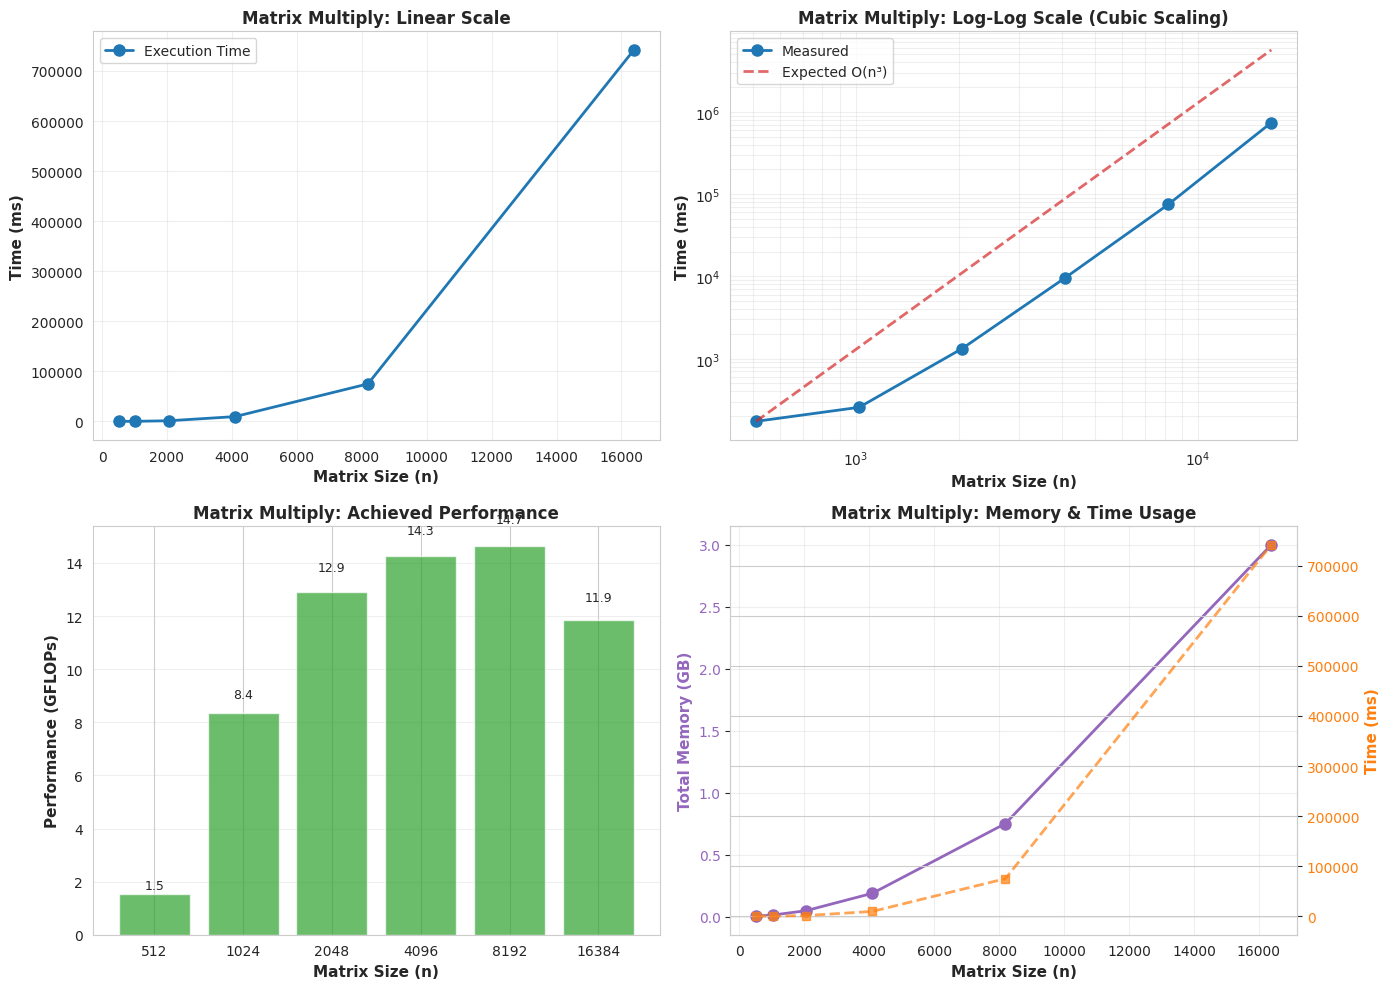

Matrix multiply charts saved to 'matrix_multiply_analysis.png'


In [59]:
# Chart 1: Linear-Linear scale time vs problem size
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Linear scale
ax = axes[0, 0]
ax.plot(df_matrix['problem_size'], df_matrix['time_ms'], 'o-', linewidth=2, markersize=8, label='Execution Time')
ax.set_xlabel('Matrix Size (n)', fontsize=11, fontweight='bold')
ax.set_ylabel('Time (ms)', fontsize=11, fontweight='bold')
ax.set_title('Matrix Multiply: Linear Scale', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Log-Log scale (shows cubic scaling)
ax = axes[0, 1]
ax.loglog(df_matrix['problem_size'], df_matrix['time_ms'], 'o-', linewidth=2, markersize=8, 
          label='Measured', color='tab:blue')
# Plot expected O(n³) line
n_range = np.array([df_matrix['problem_size'].min(), df_matrix['problem_size'].max()])
t_min = df_matrix['time_ms'].iloc[0]
n_min = df_matrix['problem_size'].iloc[0]
expected = t_min * (n_range / n_min) ** 3
ax.loglog(n_range, expected, '--', linewidth=2, label='Expected O(n³)', color='tab:red', alpha=0.7)
ax.set_xlabel('Matrix Size (n)', fontsize=11, fontweight='bold')
ax.set_ylabel('Time (ms)', fontsize=11, fontweight='bold')
ax.set_title('Matrix Multiply: Log-Log Scale (Cubic Scaling)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

# GFLOPs achieved
ax = axes[1, 0]
ax.bar(df_matrix['problem_size'].astype(str), df_matrix['gflops'], color='tab:green', alpha=0.7)
ax.set_xlabel('Matrix Size (n)', fontsize=11, fontweight='bold')
ax.set_ylabel('Performance (GFLOPs)', fontsize=11, fontweight='bold')
ax.set_title('Matrix Multiply: Achieved Performance', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_matrix['gflops']):
    ax.text(i, v + v*0.05, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

# Memory usage
ax = axes[1, 1]
ax2 = ax.twinx()
ax.plot(df_matrix['problem_size'], df_matrix['memory_gb'], 'o-', linewidth=2, markersize=8, 
        label='Total Memory', color='tab:purple')
ax2.plot(df_matrix['problem_size'], df_matrix['time_ms'], 's--', linewidth=2, markersize=6, 
         label='Time', color='tab:orange', alpha=0.7)
ax.set_xlabel('Matrix Size (n)', fontsize=11, fontweight='bold')
ax.set_ylabel('Total Memory (GB)', fontsize=11, fontweight='bold', color='tab:purple')
ax2.set_ylabel('Time (ms)', fontsize=11, fontweight='bold', color='tab:orange')
ax.set_title('Matrix Multiply: Memory & Time Usage', fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelcolor='tab:purple')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('matrix_multiply_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Matrix multiply charts saved to 'matrix_multiply_analysis.png'")

In [40]:
# Compute derived metrics for matrix multiply
df_matrix['n_cubed'] = df_matrix['problem_size'] ** 3
df_matrix['memory_gb'] = (3 * df_matrix['problem_size']**2 * 4) / (1024**3)  # 3 matrices, float32
df_matrix['gflops'] = (2 * df_matrix['n_cubed']) / (df_matrix['time_ms'] * 1e6)  # GigaFLOPS
df_matrix['scaling_factor'] = df_matrix['time_ms'] / df_matrix['time_ms'].iloc[0]  # Relative to smallest

print("Matrix Multiply - Derived Metrics:")
print(df_matrix[['problem_size', 'time_ms', 'gflops', 'memory_gb', 'scaling_factor']])

# Analyze scaling behavior
print("\n" + "="*60)
print("Scaling Analysis:")
for i in range(1, len(df_matrix)):
    size_ratio = df_matrix['problem_size'].iloc[i] / df_matrix['problem_size'].iloc[i-1]
    time_ratio = df_matrix['time_ms'].iloc[i] / df_matrix['time_ms'].iloc[i-1]
    expected_cubic = size_ratio ** 3
    print(f"n: {df_matrix['problem_size'].iloc[i-1]} → {df_matrix['problem_size'].iloc[i]}: "
          f"time ratio={time_ratio:.2f}x (expected O(n³): {expected_cubic:.2f}x)")

Matrix Multiply - Derived Metrics:
   problem_size        time_ms     gflops  memory_gb  scaling_factor
0           512     173.217455   1.549702   0.002930        1.000000
1          1024     256.608534   8.368715   0.011719        1.481424
2          2048    1329.131341  12.925637   0.046875        7.673195
3          4096    9643.697350  14.251687   0.187500       55.673935
4          8192   75027.739594  14.654735   0.750000      433.141912
5         16384  742022.040651  11.854221   3.000000     4283.760206

Scaling Analysis:
n: 512 → 1024: time ratio=1.48x (expected O(n³): 8.00x)
n: 1024 → 2048: time ratio=5.18x (expected O(n³): 8.00x)
n: 2048 → 4096: time ratio=7.26x (expected O(n³): 8.00x)
n: 4096 → 8192: time ratio=7.78x (expected O(n³): 8.00x)
n: 8192 → 16384: time ratio=9.89x (expected O(n³): 8.00x)


## Section 4: Matrix Multiply Analysis

### Key Metrics:
- **Problem Size (n)**: Matrix dimension (n×n)
- **Time**: GPU kernel execution time in milliseconds
- **Scaling**: How execution time grows with matrix size
- **Operations**: O(n³) for matrix multiplication
- **Memory**: O(n²) for each matrix

In [39]:
# Split data by benchmark type
df_matrix = df[df['benchmark'] == 'matrix_multiply_omp_gpu'].copy().sort_values('problem_size')
df_pi = df[df['benchmark'] == 'monte_carlo_pi_omp_gpu'].copy().sort_values('problem_size')

print("Matrix Multiply benchmarks:", len(df_matrix), "runs")
print(df_matrix[['problem_size', 'time_ms']])

print("\n" + "="*60)
print("Monte Carlo Pi benchmarks:", len(df_pi), "runs")
print(df_pi[['problem_size', 'time_ms', 'metric1']])

Matrix Multiply benchmarks: 6 runs
   problem_size        time_ms
0           512     173.217455
1          1024     256.608534
2          2048    1329.131341
3          4096    9643.697350
4          8192   75027.739594
5         16384  742022.040651

Monte Carlo Pi benchmarks: 10 runs
    problem_size       time_ms   metric1
6      300000000    176.957602  3.141665
7      600000000    202.917913  3.141617
8     1200000000    260.904080  3.141638
9     2400000000    351.457628  3.141618
10    4800000000    554.583883  3.141613
11    9600000000    981.549412  3.141593
12   19200000000   1831.387456  3.141585
13   38400000000   3524.562108  3.141585
14   76800000000   6886.727258  3.141592
15  153600000000  13633.166792  3.141595


## Section 3: Split Data by Benchmark

In [38]:
# Ensure numeric columns are properly typed
df['problem_size'] = pd.to_numeric(df['problem_size'])
df['gpu_count'] = pd.to_numeric(df['gpu_count'])
df['time_ms'] = pd.to_numeric(df['time_ms'])
df['metric1'] = pd.to_numeric(df['metric1'])

# Handle metric2 (may have NaN or empty values)
df['metric2'] = pd.to_numeric(df['metric2'], errors='coerce')

# Remove any fully empty rows
df = df.dropna(subset=['benchmark', 'problem_size', 'time_ms'])

print("Cleaned data shape:", df.shape)
print("\nData info after cleaning:")
print(df.info())
print("\nFirst few rows after cleaning:")
print(df.head())

Cleaned data shape: (30, 6)

Data info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   benchmark     30 non-null     object 
 1   problem_size  30 non-null     int64  
 2   gpu_count     30 non-null     int64  
 3   time_ms       30 non-null     float64
 4   metric1       30 non-null     float64
 5   metric2       20 non-null     float64
dtypes: float64(3), int64(2), object(1)
memory usage: 1.5+ KB
None

First few rows after cleaning:
                 benchmark  problem_size  gpu_count       time_ms  \
0  matrix_multiply_omp_gpu           512          1    173.217455   
1  matrix_multiply_omp_gpu          1024          1    256.608534   
2  matrix_multiply_omp_gpu          2048          1   1329.131341   
3  matrix_multiply_omp_gpu          4096          1   9643.697350   
4  matrix_multiply_omp_gpu          8192          1  75

## Section 2: Clean and Prepare Data

In [2]:
import os

print(os.getcwd())

/net/afscra/people/plgdawidz112002/labs


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load the benchmark results
csv_path = Path('/net/people/plgrid/plgdawidz112002/mpr/proj2/benchmark_results_benchmarks_gpu_20028643.csv')
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print("\nFirst rows:")
print(df.head(10))
print("\nColumn names and types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (30, 6)

First rows:
                 benchmark  problem_size  gpu_count        time_ms  \
0  matrix_multiply_omp_gpu           512          1     173.217455   
1  matrix_multiply_omp_gpu          1024          1     256.608534   
2  matrix_multiply_omp_gpu          2048          1    1329.131341   
3  matrix_multiply_omp_gpu          4096          1    9643.697350   
4  matrix_multiply_omp_gpu          8192          1   75027.739594   
5  matrix_multiply_omp_gpu         16384          1  742022.040651   
6   monte_carlo_pi_omp_gpu     300000000          1     176.957602   
7   monte_carlo_pi_omp_gpu     600000000          1     202.917913   
8   monte_carlo_pi_omp_gpu    1200000000          1     260.904080   
9   monte_carlo_pi_omp_gpu    2400000000          1     351.457628   

        metric1       metric2  
0  1.610604e+09           NaN  
1  1.288488e+10           NaN  
2  1.030792e+11           NaN  
3  8.246337e+11           NaN  
4  6.597070e+12           NaN  
5

## Section 1: Load and Inspect Data

# GPU Benchmark Analysis: Matrix Multiply vs Monte Carlo Pi

This notebook analyzes performance benchmarks from two GPU kernels run on NVIDIA Tesla V100:
- **Matrix Multiply**: Dense linear algebra computation
- **Monte Carlo Pi**: Stochastic Monte Carlo estimation

We'll examine scaling behavior, performance trends, and comparative metrics.

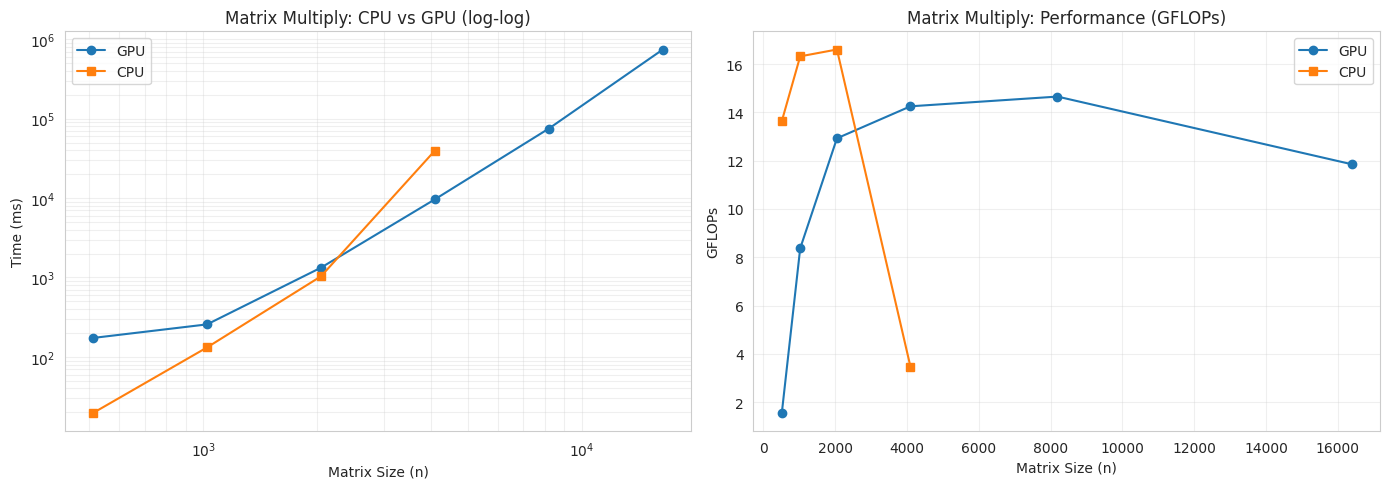

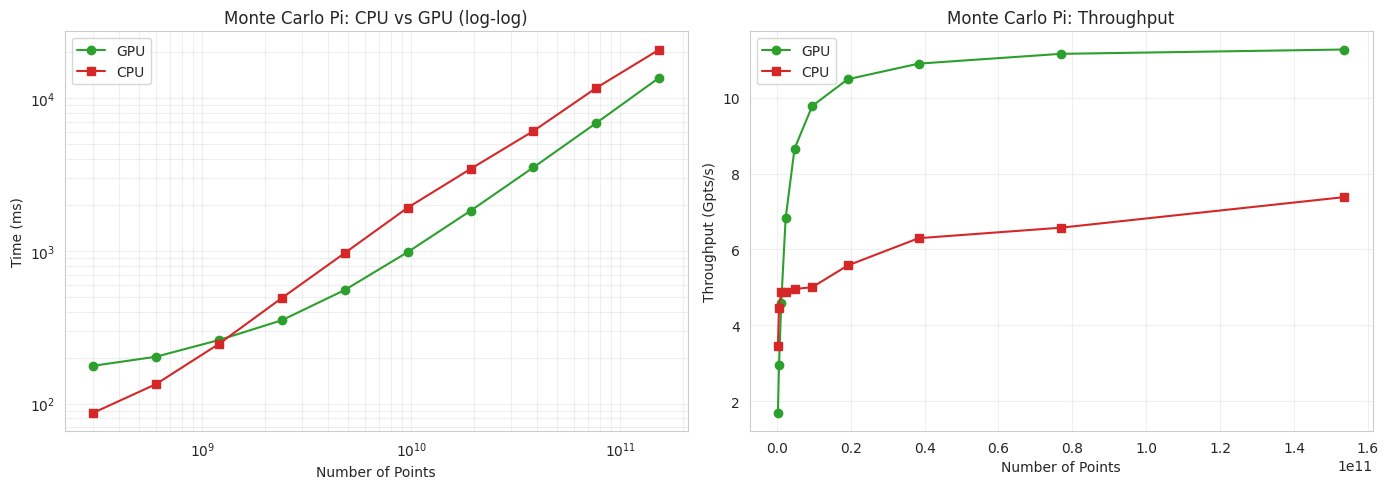

Matrix Multiply: GPU staje się szybsze dla n=4096 (CPU: 39651.32 ms, GPU: 9643.70 ms)
Monte Carlo Pi: GPU staje się szybsze dla 2.40e+09 punktów (CPU: 491.25 ms, GPU: 351.46 ms)


In [57]:
# Przygotuj dane CPU
df_matrix_cpu = df[(df['benchmark'] == 'matrix_multiply_cpu')].copy().sort_values('problem_size')
df_pi_cpu = df[(df['benchmark'] == 'monte_carlo_pi_cpu')].copy().sort_values('problem_size')

# Sprawdź czy są dane CPU
if df_matrix_cpu.empty or df_pi_cpu.empty:
  print("Brak danych CPU w ramce df.")
else:
  # Matrix Multiply CPU: metryki pochodne
  df_matrix_cpu['n_cubed'] = df_matrix_cpu['problem_size'] ** 3
  df_matrix_cpu['memory_gb'] = (3 * df_matrix_cpu['problem_size']**2 * 4) / (1024**3)
  df_matrix_cpu['gflops'] = (2 * df_matrix_cpu['n_cubed']) / (df_matrix_cpu['time_ms'] * 1e6)
  df_matrix_cpu['scaling_factor'] = df_matrix_cpu['time_ms'] / df_matrix_cpu['time_ms'].iloc[0]

  # Monte Carlo Pi CPU: metryki pochodne
  df_pi_cpu['pi_estimate'] = df_pi_cpu['metric1']
  df_pi_cpu['pi_error'] = np.abs(df_pi_cpu['pi_estimate'] - pi_true)
  df_pi_cpu['pi_error_pct'] = (df_pi_cpu['pi_error'] / pi_true) * 100
  df_pi_cpu['throughput_gpts'] = df_pi_cpu['problem_size'] / (df_pi_cpu['time_ms'] * 1e6)
  df_pi_cpu['scaling_factor'] = df_pi_cpu['time_ms'] / df_pi_cpu['time_ms'].iloc[0]

  # Wykresy Matrix Multiply: CPU vs GPU
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # 1. Czas vs rozmiar macierzy (log-log)
  ax = axes[0]
  ax.loglog(df_matrix['problem_size'], df_matrix['time_ms'], 'o-', label='GPU', color='tab:blue')
  ax.loglog(df_matrix_cpu['problem_size'], df_matrix_cpu['time_ms'], 's-', label='CPU', color='tab:orange')
  ax.set_xlabel('Matrix Size (n)')
  ax.set_ylabel('Time (ms)')
  ax.set_title('Matrix Multiply: CPU vs GPU (log-log)')
  ax.legend()
  ax.grid(True, which='both', alpha=0.3)

  # 2. GFLOPs CPU vs GPU
  ax = axes[1]
  ax.plot(df_matrix['problem_size'], df_matrix['gflops'], 'o-', label='GPU', color='tab:blue')
  ax.plot(df_matrix_cpu['problem_size'], df_matrix_cpu['gflops'], 's-', label='CPU', color='tab:orange')
  ax.set_xlabel('Matrix Size (n)')
  ax.set_ylabel('GFLOPs')
  ax.set_title('Matrix Multiply: Performance (GFLOPs)')
  ax.legend()
  ax.grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()

  # Wykresy Monte Carlo Pi: CPU vs GPU
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # 1. Czas vs liczba punktów (log-log)
  ax = axes[0]
  ax.loglog(df_pi['problem_size'], df_pi['time_ms'], 'o-', label='GPU', color='tab:green')
  ax.loglog(df_pi_cpu['problem_size'], df_pi_cpu['time_ms'], 's-', label='CPU', color='tab:red')
  ax.set_xlabel('Number of Points')
  ax.set_ylabel('Time (ms)')
  ax.set_title('Monte Carlo Pi: CPU vs GPU (log-log)')
  ax.legend()
  ax.grid(True, which='both', alpha=0.3)

  # 2. Throughput CPU vs GPU
  ax = axes[1]
  ax.plot(df_pi['problem_size'], df_pi['throughput_gpts'], 'o-', label='GPU', color='tab:green')
  ax.plot(df_pi_cpu['problem_size'], df_pi_cpu['throughput_gpts'], 's-', label='CPU', color='tab:red')
  ax.set_xlabel('Number of Points')
  ax.set_ylabel('Throughput (Gpts/s)')
  ax.set_title('Monte Carlo Pi: Throughput')
  ax.legend()
  ax.grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()

  # Porównanie CPU vs GPU: punkt przecięcia (gdzie GPU staje się szybsze)
  def find_crossover(cpu_df, gpu_df, size_col='problem_size', time_col='time_ms'):
    # Dopasuj rozmiary wspólne
    sizes = np.intersect1d(cpu_df[size_col], gpu_df[size_col])
    if len(sizes) == 0:
      return None
    cpu_times = cpu_df.set_index(size_col).loc[sizes][time_col].values
    gpu_times = gpu_df.set_index(size_col).loc[sizes][time_col].values
    for s, t_cpu, t_gpu in zip(sizes, cpu_times, gpu_times):
      if t_gpu < t_cpu:
        return s, t_cpu, t_gpu
    return None

  cross_matrix = find_crossover(df_matrix_cpu, df_matrix)
  cross_pi = find_crossover(df_pi_cpu, df_pi)

  if cross_matrix:
    print(f"Matrix Multiply: GPU staje się szybsze dla n={cross_matrix[0]} (CPU: {cross_matrix[1]:.2f} ms, GPU: {cross_matrix[2]:.2f} ms)")
  else:
    print("Matrix Multiply: GPU nie staje się szybsze dla żadnego rozmiaru z próby.")

  if cross_pi:
    print(f"Monte Carlo Pi: GPU staje się szybsze dla {cross_pi[0]:.2e} punktów (CPU: {cross_pi[1]:.2f} ms, GPU: {cross_pi[2]:.2f} ms)")
  else:
    print("Monte Carlo Pi: GPU nie staje się szybsze dla żadnego rozmiaru z próby.")

## Section 8: GPU Speedup Analysis

Comparison of GPU speedup relative to CPU baseline across problem sizes.

Matrix Multiply Speedup Range: 0.11x to 4.11x
Monte Carlo Pi Speedup Range: 0.49x to 1.95x


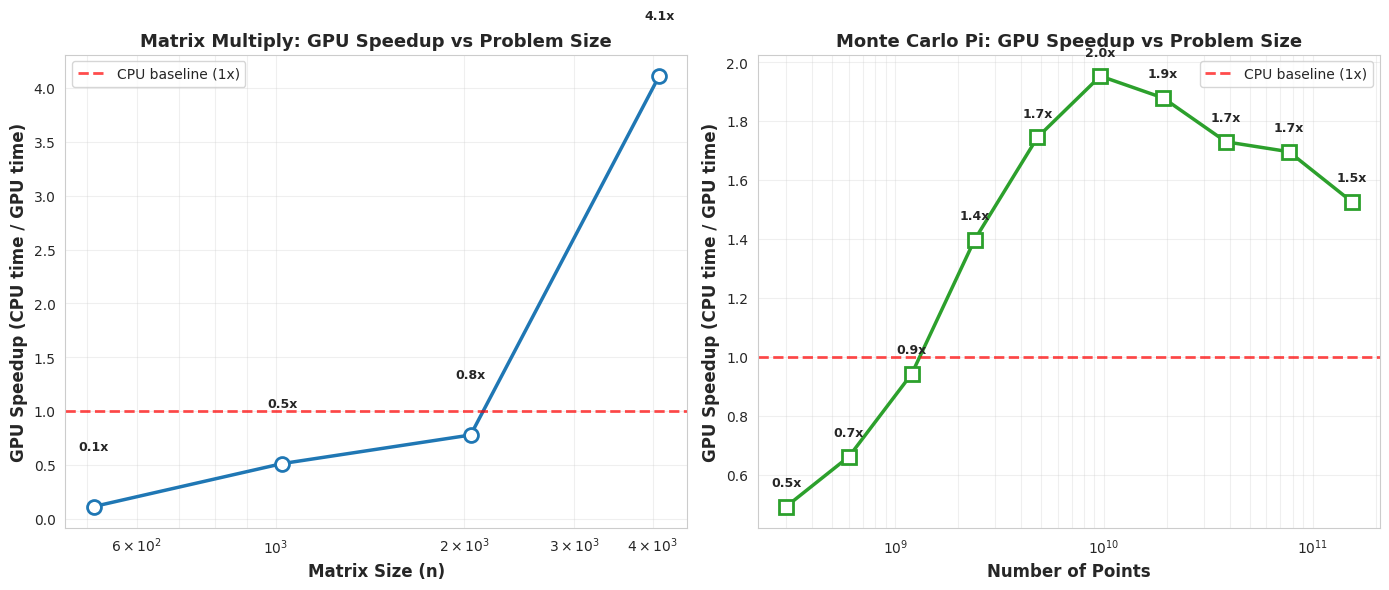


✅ GPU Speedup chart saved to 'gpu_speedup_analysis.png'

GPU SPEEDUP SUMMARY

📊 Matrix Multiply:
   • Average Speedup: 1.38x
   • Min Speedup: 0.11x (n=512)
   • Max Speedup: 4.11x (n=4096)

🎲 Monte Carlo Pi:
   • Average Speedup: 1.40x
   • Min Speedup: 0.49x (3.00e+08 points)
   • Max Speedup: 1.95x (9.60e+09 points)


In [58]:
if not df_matrix_cpu.empty and not df_pi_cpu.empty:
    # Wykres GPU Speedup
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Matrix Multiply Speedup
    ax = axes[0]
    
    # Znajdź wspólne rozmiary
    common_matrix_sizes = np.intersect1d(df_matrix['problem_size'], df_matrix_cpu['problem_size'])
    
    if len(common_matrix_sizes) > 0:
        matrix_speedup = []
        matrix_sizes = []
        
        for size in common_matrix_sizes:
            cpu_time = df_matrix_cpu[df_matrix_cpu['problem_size'] == size]['time_ms'].values[0]
            gpu_time = df_matrix[df_matrix['problem_size'] == size]['time_ms'].values[0]
            speedup = cpu_time / gpu_time
            matrix_speedup.append(speedup)
            matrix_sizes.append(size)
        
        ax.semilogx(matrix_sizes, matrix_speedup, 'o-', linewidth=2.5, markersize=10, 
                    color='tab:blue', markerfacecolor='white', markeredgewidth=2)
        ax.axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='CPU baseline (1x)')
        
        # Dodaj adnotacje z wartościami speedup
        for i, (size, speedup) in enumerate(zip(matrix_sizes, matrix_speedup)):
            ax.text(size, speedup + 0.5, f'{speedup:.1f}x', 
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.set_xlabel('Matrix Size (n)', fontsize=12, fontweight='bold')
        ax.set_ylabel('GPU Speedup (CPU time / GPU time)', fontsize=12, fontweight='bold')
        ax.set_title('Matrix Multiply: GPU Speedup vs Problem Size', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(fontsize=10)
        
        print(f"Matrix Multiply Speedup Range: {min(matrix_speedup):.2f}x to {max(matrix_speedup):.2f}x")
    else:
        ax.text(0.5, 0.5, 'No common problem sizes', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Matrix Multiply: GPU Speedup (No Data)')

    # Monte Carlo Pi Speedup
    ax = axes[1]
    
    # Znajdź wspólne rozmiary
    common_pi_sizes = np.intersect1d(df_pi['problem_size'], df_pi_cpu['problem_size'])
    
    if len(common_pi_sizes) > 0:
        pi_speedup = []
        pi_sizes = []
        
        for size in common_pi_sizes:
            cpu_time = df_pi_cpu[df_pi_cpu['problem_size'] == size]['time_ms'].values[0]
            gpu_time = df_pi[df_pi['problem_size'] == size]['time_ms'].values[0]
            speedup = cpu_time / gpu_time
            pi_speedup.append(speedup)
            pi_sizes.append(size)
        
        ax.semilogx(pi_sizes, pi_speedup, 's-', linewidth=2.5, markersize=10, 
                    color='tab:green', markerfacecolor='white', markeredgewidth=2)
        ax.axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='CPU baseline (1x)')
        
        # Dodaj adnotacje z wartościami speedup
        for i, (size, speedup) in enumerate(zip(pi_sizes, pi_speedup)):
            ax.text(size, speedup + max(pi_speedup)*0.03, f'{speedup:.1f}x', 
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.set_xlabel('Number of Points', fontsize=12, fontweight='bold')
        ax.set_ylabel('GPU Speedup (CPU time / GPU time)', fontsize=12, fontweight='bold')
        ax.set_title('Monte Carlo Pi: GPU Speedup vs Problem Size', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(fontsize=10)
        
        print(f"Monte Carlo Pi Speedup Range: {min(pi_speedup):.2f}x to {max(pi_speedup):.2f}x")
    else:
        ax.text(0.5, 0.5, 'No common problem sizes', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Monte Carlo Pi: GPU Speedup (No Data)')

    plt.tight_layout()
    plt.savefig('gpu_speedup_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✅ GPU Speedup chart saved to 'gpu_speedup_analysis.png'")
    
    # Podsumowanie statystyczne
    if len(common_matrix_sizes) > 0 and len(common_pi_sizes) > 0:
        print("\n" + "="*70)
        print("GPU SPEEDUP SUMMARY")
        print("="*70)
        print(f"\n📊 Matrix Multiply:")
        print(f"   • Average Speedup: {np.mean(matrix_speedup):.2f}x")
        print(f"   • Min Speedup: {min(matrix_speedup):.2f}x (n={matrix_sizes[matrix_speedup.index(min(matrix_speedup))]})")
        print(f"   • Max Speedup: {max(matrix_speedup):.2f}x (n={matrix_sizes[matrix_speedup.index(max(matrix_speedup))]})")
        
        print(f"\n🎲 Monte Carlo Pi:")
        print(f"   • Average Speedup: {np.mean(pi_speedup):.2f}x")
        print(f"   • Min Speedup: {min(pi_speedup):.2f}x ({pi_sizes[pi_speedup.index(min(pi_speedup))]:.2e} points)")
        print(f"   • Max Speedup: {max(pi_speedup):.2f}x ({pi_sizes[pi_speedup.index(max(pi_speedup))]:.2e} points)")
else:
    print("⚠️ No CPU data available for speedup analysis")

## Section 9: CPU Baseline Metrics

Summary of CPU performance metrics for comparison with GPU results.

In [51]:
if not df_matrix_cpu.empty:
    print("Matrix Multiply CPU - Derived Metrics:")
    print(df_matrix_cpu[['problem_size', 'time_ms', 'gflops', 'memory_gb', 'scaling_factor']])

    # Analyze scaling behavior
    print("\n" + "="*60)
    print("CPU Scaling Analysis:")
    for i in range(1, len(df_matrix_cpu)):
        size_ratio = df_matrix_cpu['problem_size'].iloc[i] / df_matrix_cpu['problem_size'].iloc[i-1]
        time_ratio = df_matrix_cpu['time_ms'].iloc[i] / df_matrix_cpu['time_ms'].iloc[i-1]
        expected_cubic = size_ratio ** 3
        print(f"n: {df_matrix_cpu['problem_size'].iloc[i-1]} → {df_matrix_cpu['problem_size'].iloc[i]}: "
              f"time ratio={time_ratio:.2f}x (expected O(n³): {expected_cubic:.2f}x)")
else:
    print("⚠️ No CPU matrix multiply data for derived metrics")

Matrix Multiply CPU - Derived Metrics:
    problem_size       time_ms     gflops  memory_gb  scaling_factor
16           512     19.682670  13.638163   0.002930        1.000000
17          1024    131.576176  16.321219   0.011719        6.684874
18          2048   1034.646762  16.604574   0.046875       52.566383
19          4096  39651.317860   3.466189   0.187500     2014.529424

CPU Scaling Analysis:
n: 512 → 1024: time ratio=6.68x (expected O(n³): 8.00x)
n: 1024 → 2048: time ratio=7.86x (expected O(n³): 8.00x)
n: 2048 → 4096: time ratio=38.32x (expected O(n³): 8.00x)


In [52]:
if not df_pi_cpu.empty:
    print("Monte Carlo Pi CPU - Derived Metrics:")
    print(df_pi_cpu[['problem_size', 'time_ms', 'pi_estimate', 'pi_error', 'pi_error_pct', 'throughput_gpts']])

    # Linear relationship analysis
    print("\n" + "="*60)
    print("CPU Scaling Analysis (should be linear: O(n)):")
    for i in range(1, len(df_pi_cpu)):
        size_ratio = df_pi_cpu['problem_size'].iloc[i] / df_pi_cpu['problem_size'].iloc[i-1]
        time_ratio = df_pi_cpu['time_ms'].iloc[i] / df_pi_cpu['time_ms'].iloc[i-1]
        print(f"Points: {df_pi_cpu['problem_size'].iloc[i-1]:.2e} → {df_pi_cpu['problem_size'].iloc[i]:.2e}: "
              f"time ratio={time_ratio:.3f}x (expected O(n): {size_ratio:.3f}x)")
else:
    print("⚠️ No CPU Monte Carlo Pi data for derived metrics")

Monte Carlo Pi CPU - Derived Metrics:
    problem_size       time_ms  pi_estimate      pi_error  pi_error_pct  \
20     300000000     86.976963     3.141636  4.326641e-05      0.001377   
21     600000000    134.181306     3.141606  1.366641e-05      0.000435   
22    1200000000    245.938589     3.141644  5.093641e-05      0.001621   
23    2400000000    491.247245     3.141602  8.936410e-06      0.000284   
24    4800000000    967.911028     3.141587  5.963590e-06      0.000190   
25    9600000000   1917.249722     3.141601  8.286410e-06      0.000264   
26   19200000000   3441.091317     3.141596  3.746410e-06      0.000119   
27   38400000000   6097.360851     3.141588  4.833590e-06      0.000154   
28   76800000000  11682.898586     3.141591  1.513590e-06      0.000048   
29  153600000000  20814.073548     3.141594  9.064102e-07      0.000029   

    throughput_gpts  
20         3.449189  
21         4.471562  
22         4.879267  
23         4.885524  
24         4.959133  
25  

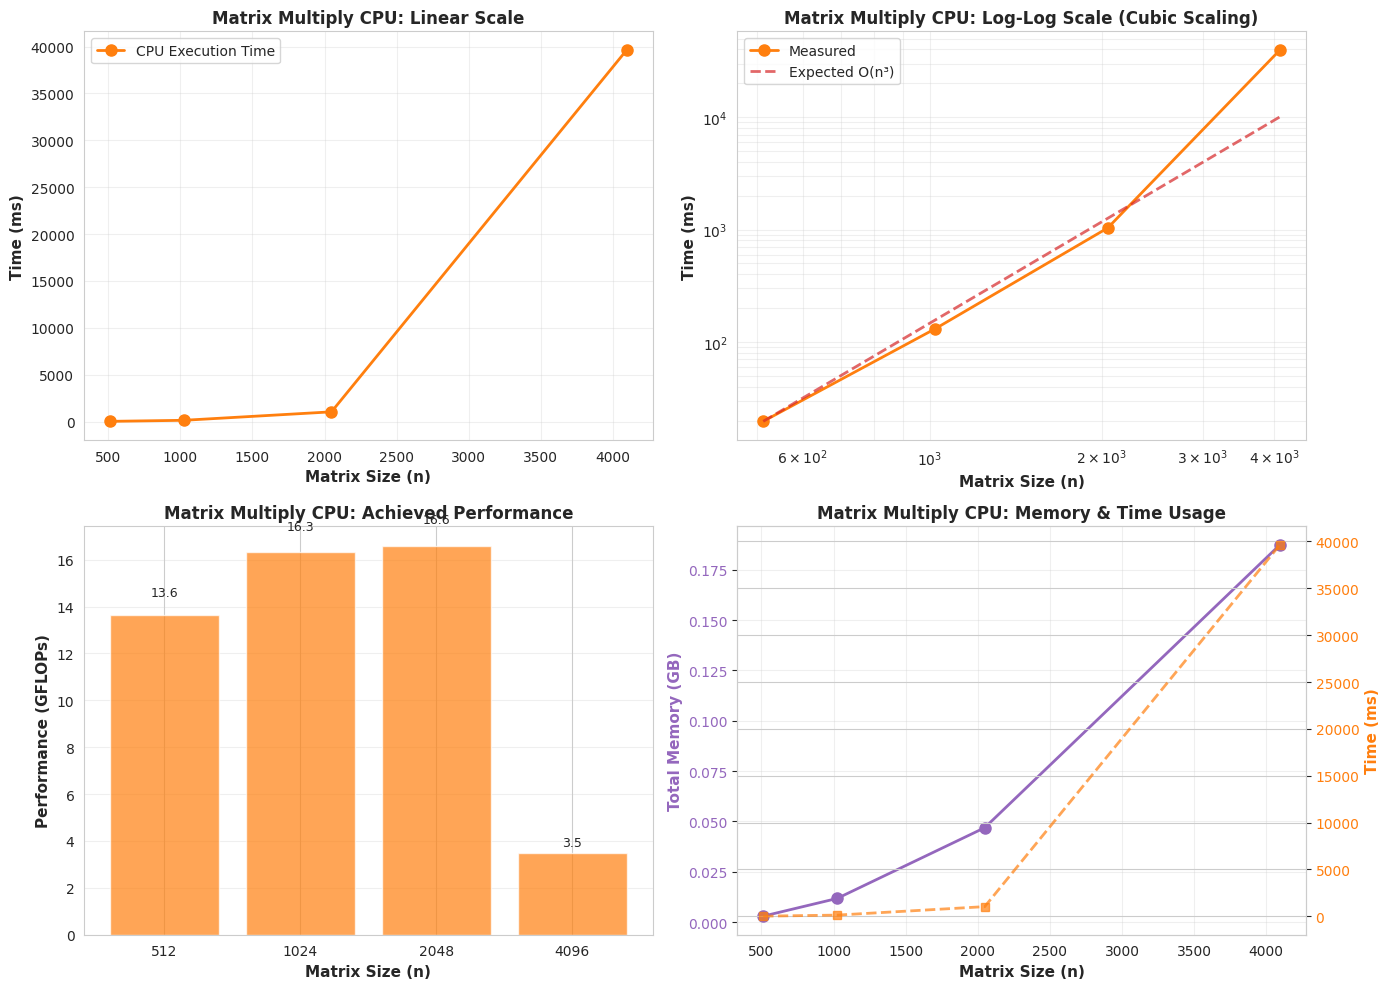

Matrix multiply CPU charts saved to 'matrix_multiply_cpu_analysis.png'


In [53]:
if not df_matrix_cpu.empty:
    # Chart: Matrix Multiply CPU Analysis (4 subplots)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Linear scale
    ax = axes[0, 0]
    ax.plot(df_matrix_cpu['problem_size'], df_matrix_cpu['time_ms'], 'o-', linewidth=2, markersize=8, 
            label='CPU Execution Time', color='tab:orange')
    ax.set_xlabel('Matrix Size (n)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Time (ms)', fontsize=11, fontweight='bold')
    ax.set_title('Matrix Multiply CPU: Linear Scale', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Log-Log scale (shows cubic scaling)
    ax = axes[0, 1]
    ax.loglog(df_matrix_cpu['problem_size'], df_matrix_cpu['time_ms'], 'o-', linewidth=2, markersize=8, 
              label='Measured', color='tab:orange')
    # Plot expected O(n³) line
    n_range = np.array([df_matrix_cpu['problem_size'].min(), df_matrix_cpu['problem_size'].max()])
    t_min = df_matrix_cpu['time_ms'].iloc[0]
    n_min = df_matrix_cpu['problem_size'].iloc[0]
    expected = t_min * (n_range / n_min) ** 3
    ax.loglog(n_range, expected, '--', linewidth=2, label='Expected O(n³)', color='tab:red', alpha=0.7)
    ax.set_xlabel('Matrix Size (n)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Time (ms)', fontsize=11, fontweight='bold')
    ax.set_title('Matrix Multiply CPU: Log-Log Scale (Cubic Scaling)', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')

    # GFLOPs achieved
    ax = axes[1, 0]
    ax.bar(df_matrix_cpu['problem_size'].astype(str), df_matrix_cpu['gflops'], color='tab:orange', alpha=0.7)
    ax.set_xlabel('Matrix Size (n)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Performance (GFLOPs)', fontsize=11, fontweight='bold')
    ax.set_title('Matrix Multiply CPU: Achieved Performance', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(df_matrix_cpu['gflops']):
        ax.text(i, v + v*0.05, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

    # Memory usage
    ax = axes[1, 1]
    ax2 = ax.twinx()
    ax.plot(df_matrix_cpu['problem_size'], df_matrix_cpu['memory_gb'], 'o-', linewidth=2, markersize=8, 
            label='Total Memory', color='tab:purple')
    ax2.plot(df_matrix_cpu['problem_size'], df_matrix_cpu['time_ms'], 's--', linewidth=2, markersize=6, 
             label='Time', color='tab:orange', alpha=0.7)
    ax.set_xlabel('Matrix Size (n)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Total Memory (GB)', fontsize=11, fontweight='bold', color='tab:purple')
    ax2.set_ylabel('Time (ms)', fontsize=11, fontweight='bold', color='tab:orange')
    ax.set_title('Matrix Multiply CPU: Memory & Time Usage', fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelcolor='tab:purple')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('matrix_multiply_cpu_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Matrix multiply CPU charts saved to 'matrix_multiply_cpu_analysis.png'")
else:
    print("⚠️ No CPU matrix multiply data available")

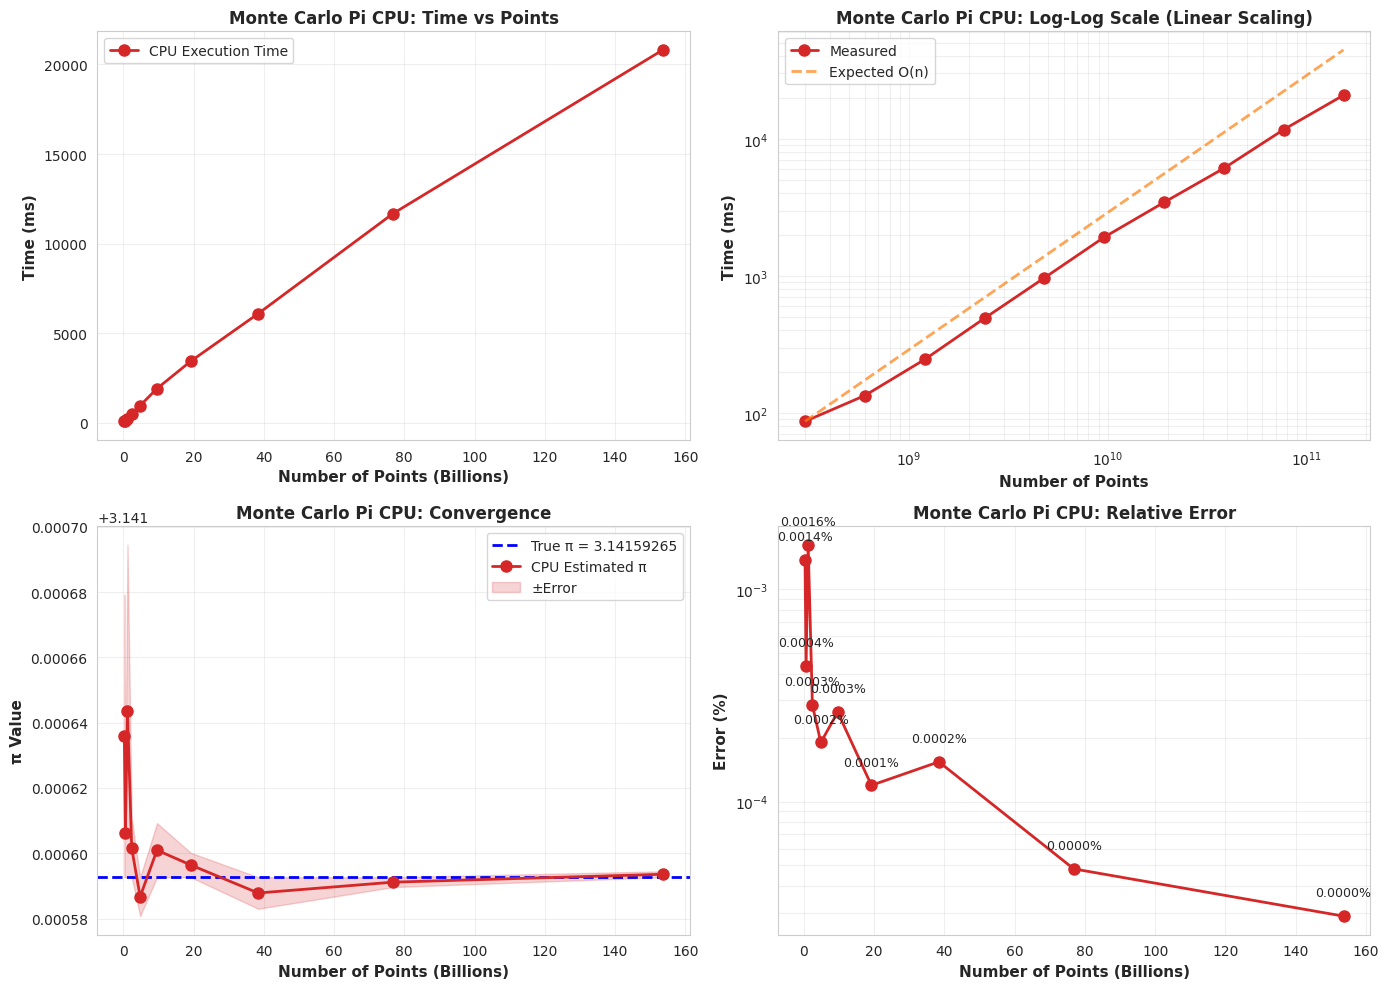

Monte Carlo Pi CPU charts saved to 'monte_carlo_pi_cpu_analysis.png'


In [54]:
if not df_pi_cpu.empty:
    # Chart: Monte Carlo Pi CPU Analysis (4 subplots)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Time vs Points (linear scale)
    ax = axes[0, 0]
    ax.plot(df_pi_cpu['problem_size']/1e9, df_pi_cpu['time_ms'], 'o-', linewidth=2, markersize=8, 
            label='CPU Execution Time', color='tab:red')
    ax.set_xlabel('Number of Points (Billions)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Time (ms)', fontsize=11, fontweight='bold')
    ax.set_title('Monte Carlo Pi CPU: Time vs Points', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Log-Log scale (shows linear scaling in log space)
    ax = axes[0, 1]
    ax.loglog(df_pi_cpu['problem_size'], df_pi_cpu['time_ms'], 'o-', linewidth=2, markersize=8, 
              label='Measured', color='tab:red')
    # Plot expected O(n) line
    n_range = np.array([df_pi_cpu['problem_size'].min(), df_pi_cpu['problem_size'].max()])
    t_min = df_pi_cpu['time_ms'].iloc[0]
    n_min = df_pi_cpu['problem_size'].iloc[0]
    expected_linear = t_min * (n_range / n_min)
    ax.loglog(n_range, expected_linear, '--', linewidth=2, label='Expected O(n)', color='tab:orange', alpha=0.7)
    ax.set_xlabel('Number of Points', fontsize=11, fontweight='bold')
    ax.set_ylabel('Time (ms)', fontsize=11, fontweight='bold')
    ax.set_title('Monte Carlo Pi CPU: Log-Log Scale (Linear Scaling)', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')

    # Pi estimate convergence
    ax = axes[1, 0]
    ax.axhline(y=pi_true, color='blue', linestyle='--', linewidth=2, label=f'True π = {pi_true:.8f}')
    ax.plot(df_pi_cpu['problem_size']/1e9, df_pi_cpu['pi_estimate'], 'o-', linewidth=2, markersize=8, 
            label='CPU Estimated π', color='tab:red')
    ax.fill_between(df_pi_cpu['problem_size']/1e9, 
                     df_pi_cpu['pi_estimate'] - df_pi_cpu['pi_error'],
                     df_pi_cpu['pi_estimate'] + df_pi_cpu['pi_error'],
                     alpha=0.2, color='tab:red', label='±Error')
    ax.set_xlabel('Number of Points (Billions)', fontsize=11, fontweight='bold')
    ax.set_ylabel('π Value', fontsize=11, fontweight='bold')
    ax.set_title('Monte Carlo Pi CPU: Convergence', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Error percentage
    ax = axes[1, 1]
    ax.semilogy(df_pi_cpu['problem_size']/1e9, df_pi_cpu['pi_error_pct'], 'o-', linewidth=2, markersize=8, 
                color='tab:red')
    ax.set_xlabel('Number of Points (Billions)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Error (%)', fontsize=11, fontweight='bold')
    ax.set_title('Monte Carlo Pi CPU: Relative Error', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')
    for i, v in enumerate(df_pi_cpu['pi_error_pct']):
        ax.text(df_pi_cpu['problem_size'].iloc[i]/1e9, v*1.2, f'{v:.4f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('monte_carlo_pi_cpu_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Monte Carlo Pi CPU charts saved to 'monte_carlo_pi_cpu_analysis.png'")
else:
    print("⚠️ No CPU Monte Carlo Pi data available")